In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Daksh_Gururkul_IITG_May_2025/24_KMeans_Clustering/bank-full.csv')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'subscribed'],
      dtype='object')

# bank client data:
1. age (numeric)

2. job : type of job (categorical: 'admin.','blue-
collar','entrepreneur','housemaid','management','retired','self-
employed','services','student','technician','unemployed','unknown')

3. marital : marital status (categorical:
'divorced','married','single','unknown'; note: 'divorced' means
divorced or widowed)
4. education (categorical:
'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional
5. default: has credit in default? (categorical:
'no','yes','unknown')
6. housing: has housing loan? (categorical: 'no','yes','unknown')
7. loan: has personal loan? (categorical: 'no','yes','unknown')
 related with the last contact of the current campaign:
8. contact: contact communication type (categorical:
'cellular','telephone')
9. month: last contact month of year (categorical: 'jan', 'feb',
'mar', ..., 'nov', 'dec')
10. day_of_week: last contact day of the week (categorical:
'mon','tue','wed','thu','fri')
11. duration: last contact duration, in seconds (numeric).
Important note: this attribute highly affects the output target
(e.g., if duration=0 then y='no'). Yet, the duration is not known
before a call is performed. Also, after the end of the call y is
obviously known. Thus, this input should only be included for
benchmark purposes and should be discarded if the intention is to
have a realistic predictive model.
# other attributes:
12. campaign: number of contacts performed during this campaign
and for this client (numeric, includes last contact)
13. pdays: number of days that passed by after the client was
last contacted from a previous campaign (numeric; 999 means client
was not previously contacted)
14. previous: number of contacts performed before this campaign
and for this client (numeric)
15. poutcome: outcome of the previous marketing campaign
(categorical: 'failure','nonexistent','success')
 - social and economic context attributes
16. emp.var.rate: employment variation rate - quarterly indicator
(numeric)
17. cons.price.idx: consumer price index - monthly indicator
(numeric)
18. cons.conf.idx: consumer confidence index - monthly indicator
(numeric)
19. euribor3m: euribor 3 month rate - daily indicator (numeric)
20. nr.employed: number of employees - quarterly indicator
(numeric)
21. y - has the client subscribed a term deposit? (binary:
'yes','no')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

<Axes: xlabel='age', ylabel='Count'>

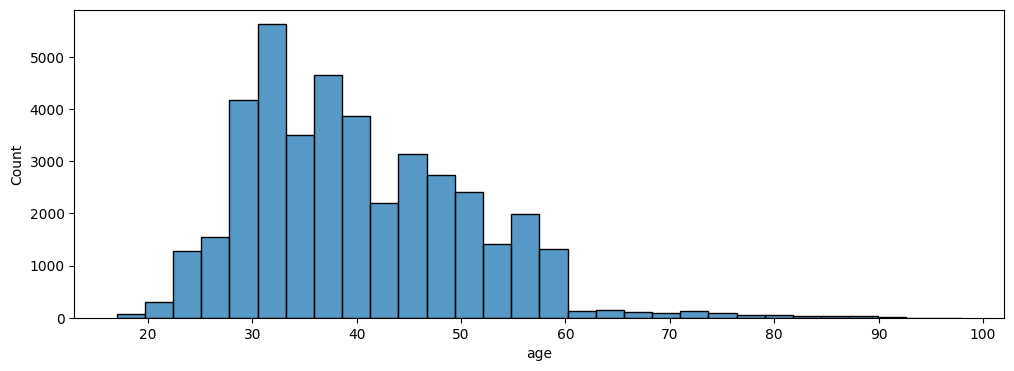

In [6]:
plt.figure(figsize=(12,4))
sns.histplot(data=df,x='age',bins=30)

<Axes: xlabel='age', ylabel='Count'>

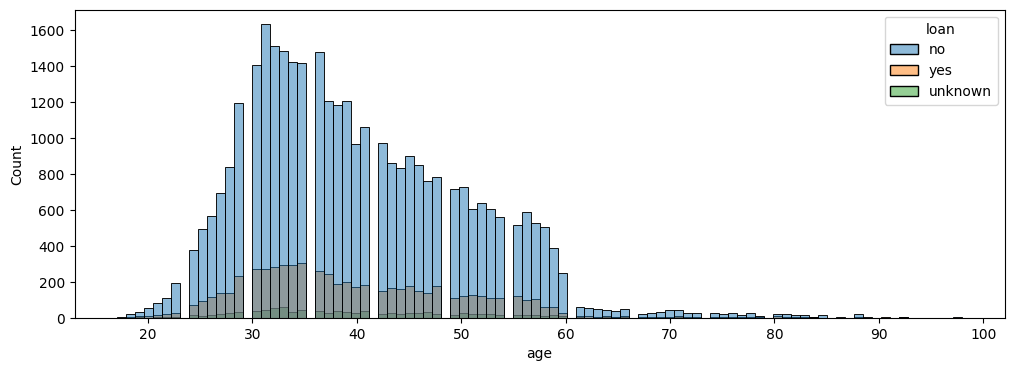

In [7]:
plt.figure(figsize=(12,4))
sns.histplot(data=df,x='age',hue='loan')

<Axes: xlabel='pdays', ylabel='Count'>

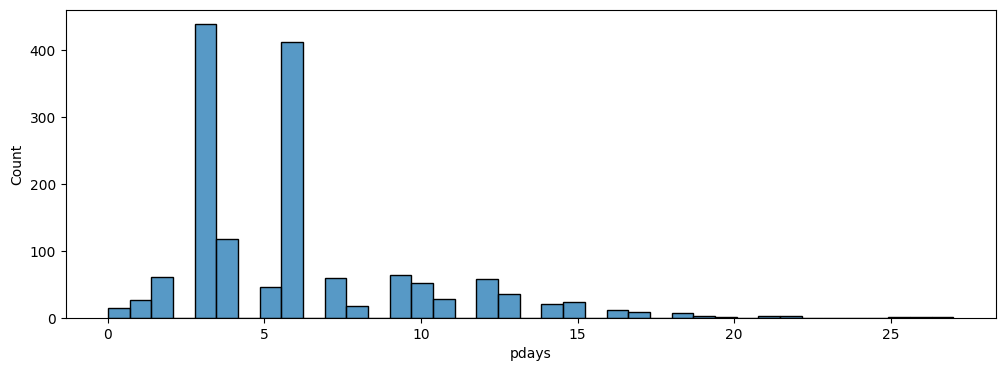

In [8]:
plt.figure(figsize=(12,4))
sns.histplot(data=df[df['pdays']!= 999],x='pdays')

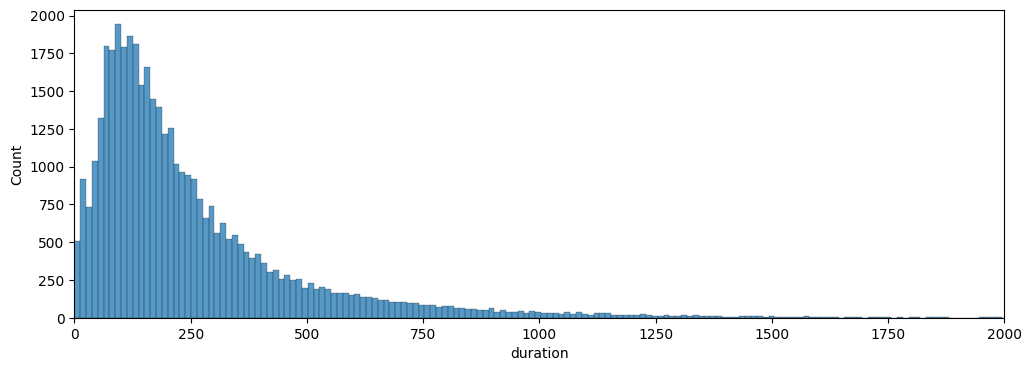

In [9]:
plt.figure(figsize=(12,4))
sns.histplot(data=df,x='duration')
plt.xlim(0,2000)
plt.show()

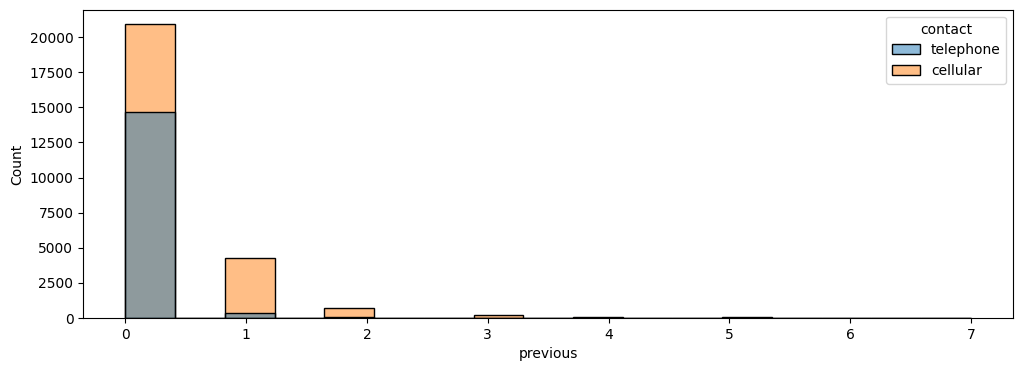

In [10]:
plt.figure(figsize=(12,4))
sns.histplot(data=df,x='previous',hue='contact')
plt.show()

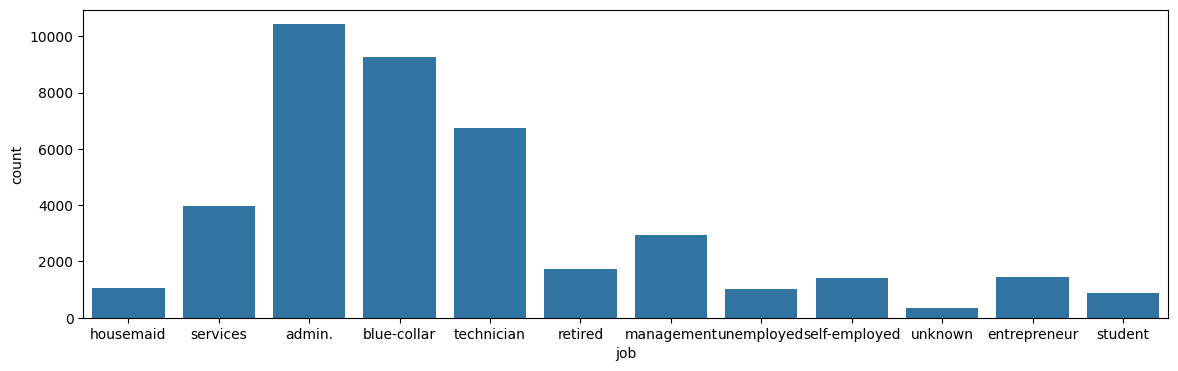

In [11]:
plt.figure(figsize=(14,4))
sns.countplot(data=df,x='job')
plt.show()

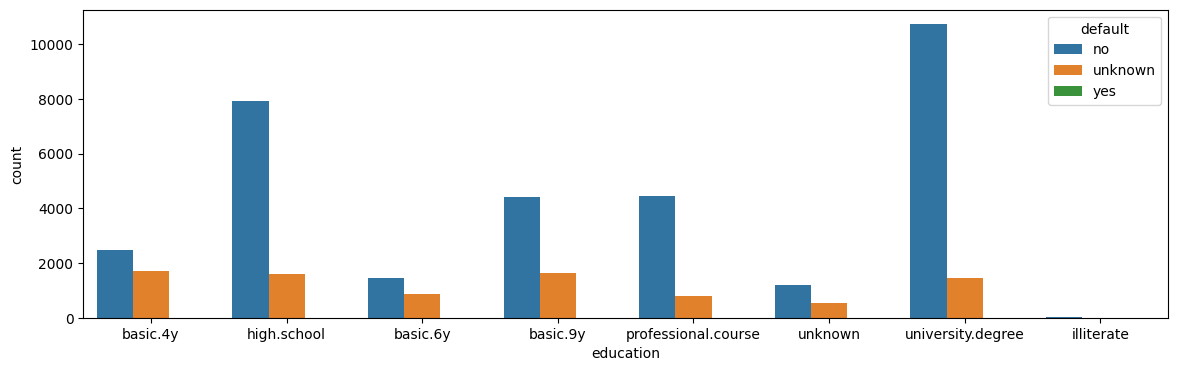

In [12]:
plt.figure(figsize=(14,4))
sns.countplot(data=df,x='education',hue='default')
plt.show()

In [13]:
X = pd.get_dummies(df)
X.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,subscribed_no,subscribed_yes
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False


In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
sc = StandardScaler()

In [16]:
scaled_X = sc.fit_transform(X)

# KMeans Model

In [17]:
from sklearn.cluster import KMeans

In [18]:
model = KMeans(n_clusters=2,max_iter=1000,random_state=50)

In [19]:
cluster_labels = model.fit_predict(scaled_X)

In [20]:
cluster_labels

array([1, 1, 1, ..., 0, 0, 0], dtype=int32)

In [21]:
X['Cluster'] = cluster_labels

In [22]:
X

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,subscribed_no,subscribed_yes,Cluster
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,1
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,1
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,1
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,1
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,334,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,False,False,False,False,False,True,False,False,True,0
41184,46,383,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,False,False,False,False,False,True,False,True,False,0
41185,56,189,2,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,False,False,False,False,False,True,False,True,False,0
41186,44,442,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,False,False,False,False,False,True,False,False,True,0


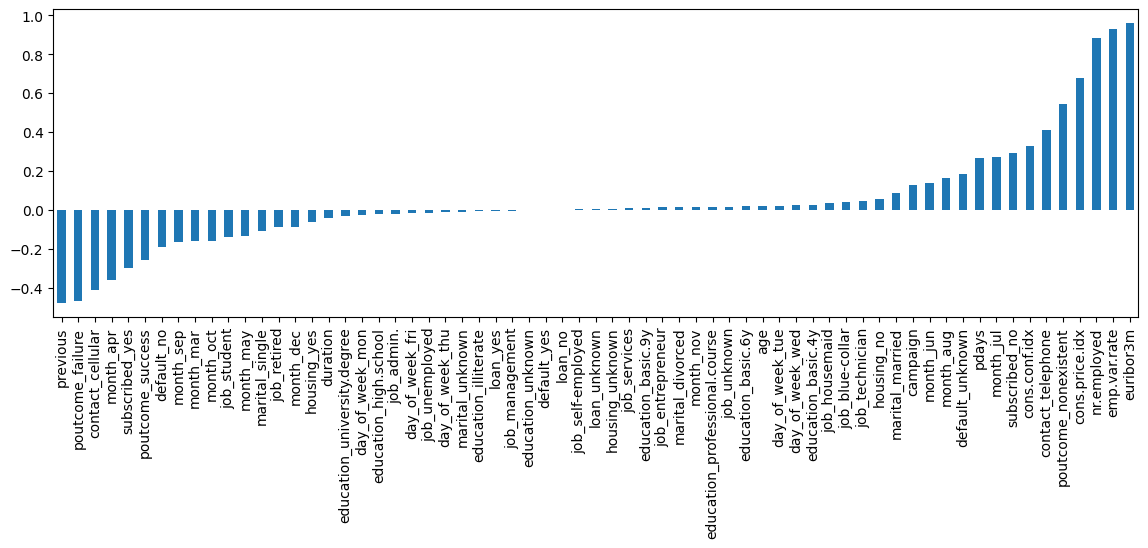

In [23]:
plt.figure(figsize=(14,4))
X.corr()['Cluster'].iloc[:-1].sort_values().plot(kind='bar')
plt.show()

# Choosing K Value

In [24]:
ssd = []

for k in range(2,10):
  model = KMeans(n_clusters=k)
  model.fit(scaled_X)

  ssd.append(model.inertia_)

Text(0, 0.5, 'Sum of Squared Distances')

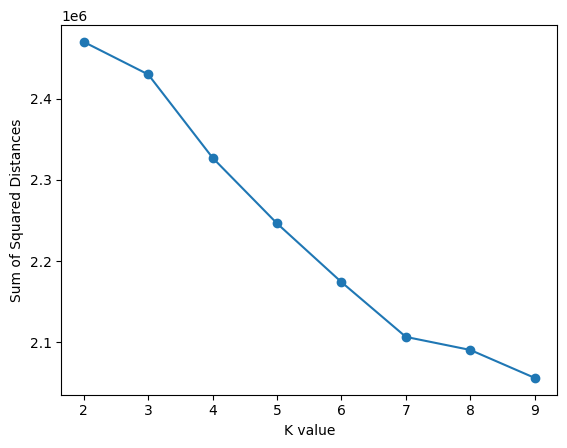

In [25]:
plt.plot(range(2,10),ssd,'o-')
plt.xlabel('K value')
plt.ylabel('Sum of Squared Distances')

<Axes: >

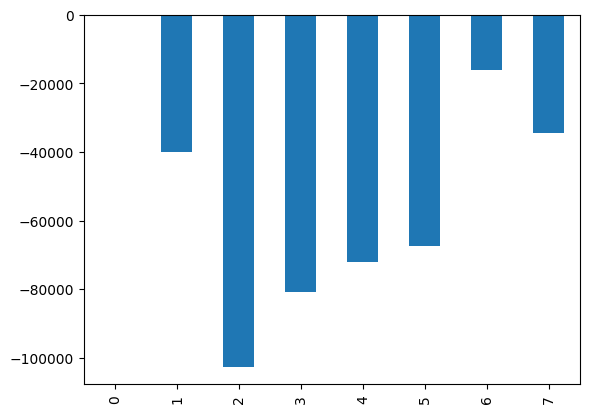

In [27]:
pd.Series(ssd).diff().plot(kind='bar')